In [8]:
# Manipulación y análisis de datos
import pandas as pd

# Cálculo científico y vectorial
import numpy as np

# Librerías para graficar
from matplotlib import pyplot

from sklearn.model_selection import train_test_split

# Módulo de optimización de scipy
from scipy import optimize

# Le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

In [5]:
# Parámetros del dataset
input_layer_size = 242  # columnas de sensores (sin timestamp ni etiquetas)
num_labels = 5          # clases de HL_Activity: 101, 102, 103, 104, 105

# Cargar y unir los 24 archivos
carpeta = "dataset"
nombres = [
    "S1-ADL1.csv",
    "S1-ADL2.dat", "S1-ADL3.dat", "S1-ADL4.dat", "S1-ADL5.dat",
    "S2-ADL1.dat", "S2-ADL2.dat", "S2-ADL3.dat", "S2-ADL4.dat", "S2-ADL5.dat",
    "S3-ADL1.dat", "S3-ADL2.dat", "S3-ADL3.dat", "S3-ADL4.dat", "S3-ADL5.dat",
    "S4-ADL1.dat", "S4-ADL2.dat", "S4-ADL3.dat", "S4-ADL4.dat", "S4-ADL5.dat",
    "S1-Drill.dat", "S2-Drill.dat", "S3-Drill.dat",
    "S4-Drill.csv"
]

dfs = []
for nombre in nombres:
    ruta = f"{carpeta}/{nombre}"
    df_temp = pd.read_csv(ruta, sep=' ', header=None)
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)

# ── Seleccionar solo las columnas que necesitamos ──
# Columna 0   → timestamp     (se elimina)
# Columnas 1–243 → sensores   (features X)
# Columna 244 → Locomotion    (se elimina)
# Columna 245 → HL_Activity   (variable objetivo y)
# Columnas 246–249 → otras etiquetas (se eliminan)

X = df.iloc[:, 1:243]   # columnas 1 a 243 → sensores
y = df.iloc[:, 244]     # columna 245 → HL_Activity

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClases encontradas en y:\n{y.value_counts()}")

X shape: (869387, 242)
y shape: (869387,)

Clases encontradas en y:
244
0      338809
105    174278
103    138449
102     88113
104     85797
101     43941
Name: count, dtype: int64


In [6]:
# Unir X e y en un solo dataframe para manipularlos juntos
df_clean = X.copy()
df_clean['y'] = y.values

# Eliminar filas sin etiqueta (y == 0) 
df_clean = df_clean[df_clean['y'] != 0]
print(f"Filas después de eliminar etiqueta 0: {df_clean.shape[0]:,}")
print(f"\nDistribución por clase antes de balancear:")
print(df_clean['y'].value_counts())

# Balancear clases
# Tomamos el mismo número de ejemplos por clase (el mínimo disponible)
min_clase = df_clean['y'].value_counts().min()
print(f"\nEjemplos por clase después de balancear: {min_clase:,}")

df_balanceado = (
    df_clean
    .groupby('y', group_keys=False)
    .apply(lambda clase: clase.sample(n=min_clase, random_state=42))
    .reset_index(drop=True)
)

print(f"\nDistribución por clase después de balancear:")
print(df_balanceado['y'].value_counts())
print(f"\nTotal de ejemplos: {df_balanceado.shape[0]:,}")

# ── Separar X e y del dataframe balanceado ──
X = df_balanceado.drop(columns=['y']).values
y = df_balanceado['y'].values

print(f"\nX shape final: {X.shape}")
print(f"y shape final: {y.shape}")

Filas después de eliminar etiqueta 0: 530,578

Distribución por clase antes de balancear:
y
105    174278
103    138449
102     88113
104     85797
101     43941
Name: count, dtype: int64

Ejemplos por clase después de balancear: 43,941


C:\Users\HP\AppData\Local\Temp\ipykernel_19764\2362953298.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda clase: clase.sample(n=min_clase, random_state=42))



Distribución por clase después de balancear:
y
101    43941
102    43941
103    43941
104    43941
105    43941
Name: count, dtype: int64

Total de ejemplos: 219,705

X shape final: (219705, 242)
y shape final: (219705,)


In [9]:
# Nombres de algunas columnas representativas de sensores
nombres_columnas = {
    1:  'BACK_acc_X',
    2:  'BACK_acc_Y', 
    3:  'BACK_acc_Z',
    4:  'HIP_acc_X',
    5:  'HIP_acc_Y',
    6:  'HIP_acc_Z',
    38: 'IMU_BACK_acc_X',
    39: 'IMU_BACK_acc_Y',
    40: 'IMU_BACK_acc_Z',
}

# dataframe de muestra con columnas seleccionadas
columnas_mostrar = [1, 2, 3, 4, 5, 6, 38, 39, 40]

df_muestra = df_balanceado[columnas_mostrar].copy()
df_muestra.columns = [nombres_columnas[c] for c in columnas_mostrar]
df_muestra['HL_Activity'] = df_balanceado['y'].map({
    101: 'Relaxing',
    102: 'Coffee time',
    103: 'Early morning',
    104: 'Cleanup',
    105: 'Sandwich time'
})

print("Muestra del dataset OPPORTUNITY (10 primeras filas):")
print(df_muestra.head(10).to_string(index=False))

Muestra del dataset OPPORTUNITY (10 primeras filas):
 BACK_acc_X  BACK_acc_Y  BACK_acc_Z  HIP_acc_X  HIP_acc_Y  HIP_acc_Z  IMU_BACK_acc_X  IMU_BACK_acc_Y  IMU_BACK_acc_Z HL_Activity
       -2.0      1006.0       270.0     -351.0      970.0       63.0          -108.0           360.0             2.0    Relaxing
     -866.0       329.0       468.0      947.0      388.0      -56.0           838.0           238.0            45.0    Relaxing
        NaN         NaN         NaN        NaN        NaN        NaN             NaN             NaN             NaN    Relaxing
      874.0        13.0      -486.0      -73.0       90.0     -990.0          -829.0          -403.0           -11.0    Relaxing
      876.0        17.0      -493.0      -69.0       97.0     -962.0          -831.0          -391.0           -22.0    Relaxing
      296.0      -693.0      -133.0     -288.0     1034.0     -157.0           -57.0           410.0           160.0    Relaxing
     -170.0      -314.0       931.0        N

In [ ]:

# Verificar cuántos NaN hay
nans = pd.DataFrame(X).isna().sum().sum()
print(f"Total de valores NaN: {nans:,}")

# Reemplazar NaN con la mediana de cada columna
df_X = pd.DataFrame(X)
df_X = df_X.fillna(df_X.median())
X = df_X.values

print(f"NaN restantes después de imputar: {pd.DataFrame(X).isna().sum().sum()}")

# Reemplazar etiquetas 101-105 por 0-4 para facilitar el modelo
etiquetas = {101: 0, 102: 1, 103: 2, 104: 3, 105: 4}
y = np.array([etiquetas[val] for val in y])
print(f"\nClases después de recodificar:")
print(np.unique(y, return_counts=True))

# División 80% entrenamiento - 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nEntrenamiento: {X_train.shape[0]:,} filas")
print(f"Prueba:        {X_test.shape[0]:,} filas")

Total de valores NaN: 1,561,113
NaN restantes después de imputar: 0

Clases después de recodificar:
(array([0, 1, 2, 3, 4]), array([43941, 43941, 43941, 43941, 43941]))

Entrenamiento: 175,764 filas
Prueba:        43,941 filas


In [10]:
# Normalización de features
# Escala todas las columnas para que tengan media 0 y desviación estándar 1
# Esto es importante para que el descenso por gradiente converja más rápido

def featureNormalize(X):
    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    # Evitar división por cero en columnas con desviación estándar = 0
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# ── Aplicar normalización solo con datos de entrenamiento ──
# mu y sigma se calculan solo sobre train para no filtrar info del test
X_train_norm, mu, sigma = featureNormalize(X_train)

# ── Aplicar los mismos mu y sigma al conjunto de prueba ──
X_test_norm = (X_test - mu) / sigma

print(f"Media de X_train_norm (debe ser ~0): {X_train_norm.mean():.6f}")
print(f"Std de X_train_norm  (debe ser ~1): {X_train_norm.std():.6f}")

Media de X_train_norm (debe ser ~0): -0.000000
Std de X_train_norm  (debe ser ~1): 1.000000


In [14]:
# Función sigmoide 
# Transforma cualquier valor real a un rango entre 0 y 1
# Se usa para calcular la probabilidad de que un ejemplo pertenezca a una clase

def sigmoid(z):
    return np.clip(1.0 / (1.0 + np.exp(-z)), 1e-10, 1 - 1e-10)

# ── Prueba de la función ──
print(f"sigmoid(0)   = {sigmoid(0)}")       # debe ser 0.5
print(f"sigmoid(100) = {sigmoid(100):.4f}") # debe ser ~1.0
print(f"sigmoid(-100)= {sigmoid(-100):.4f}")# debe ser ~0.0

sigmoid(0)   = 0.5
sigmoid(100) = 1.0000
sigmoid(-100)= 0.0000


In [15]:
# Función de costo con regularización
# Mide qué tan equivocado está el modelo en sus predicciones
# lambda_ controla la regularización para evitar overfitting

def lrCostFunction(theta, X, y, lambda_):
    m = y.size

    h = sigmoid(X.dot(theta))
    
    # Costo sin regularización
    J = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h))
    
    # Término de regularización (no se regulariza theta[0])
    J += (lambda_ / (2 * m)) * np.sum(theta[1:] ** 2)
    
    # Gradiente
    grad = (1 / m) * X.T.dot(h - y)
    
    # Regularización del gradiente (no se regulariza theta[0])
    grad[1:] += (lambda_ / m) * theta[1:]
    
    return J, grad

# Prueba rápida
m_test, n_test = X_train_norm.shape
X_test_temp = np.concatenate([np.ones((5, 1)), X_train_norm[:5]], axis=1)
theta_test  = np.zeros(n_test + 1)
y_test_temp = (y_train[:5] == 0).astype(int)

J, grad = lrCostFunction(theta_test, X_test_temp, y_test_temp, lambda_=0.1)
print(f"Costo inicial (debe ser ~0.693): {J:.4f}")
print(f"Forma del gradiente: {grad.shape}")

Costo inicial (debe ser ~0.693): 0.6931
Forma del gradiente: (243,)


In [18]:
# ── Clasificación One-vs-All ──
# Entrena K clasificadores, uno por cada clase
# Cada clasificador aprende a distinguir su clase del resto
def oneVsAll(X, y, num_labels, lambda_):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    historial_costos = []

    # Agregar término de intercepción
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in range(num_labels):
        print(f"Entrenando clasificador para clase {c}...")

        initial_theta = np.zeros(n + 1)

        # Convertir y a binario: 1 si es clase c, 0 si no
        y_binario = (y == c).astype(int)
        J_historia = []

        # Función auxiliar que guarda el costo en cada iteración
        def costo_con_historia(theta):
            J, grad = lrCostFunction(theta, X, y_binario, lambda_)
            J_historia.append(J)
            return J, grad

        # Optimizar usando scipy
        options = {'maxfun': 400}
        res = optimize.minimize(
            costo_con_historia,
            initial_theta,
            jac=True,
            method='TNC',
            options=options
        )

        all_theta[c] = res.x
        historial_costos.append(J_historia)
        print(f"  Costo final clase {c}: {res.fun:.4f}")

    return all_theta, historial_costos

# ── Entrenar el modelo ──
lambda_ = 0.1
print("Iniciando entrenamiento One-vs-All...")
print(f"Dataset de entrenamiento: {X_train_norm.shape[0]:,} filas × {X_train_norm.shape[1]} columnas")
print(f"Número de clases: {num_labels}\n")

all_theta, historial_costos = oneVsAll(X_train_norm, y_train, num_labels, lambda_)

print(f"\nEntrenamiento completado.")
print(f"Forma de all_theta: {all_theta.shape}")

Iniciando entrenamiento One-vs-All...
Dataset de entrenamiento: 175,764 filas × 242 columnas
Número de clases: 5

Entrenando clasificador para clase 0...


C:\Users\HP\AppData\Local\Temp\ipykernel_19764\701108865.py:6: RuntimeWarning: overflow encountered in exp
  return np.clip(1.0 / (1.0 + np.exp(-z)), 1e-10, 1 - 1e-10)


  Costo final clase 0: 0.0258
Entrenando clasificador para clase 1...
  Costo final clase 1: 0.2079
Entrenando clasificador para clase 2...
  Costo final clase 2: 0.1081
Entrenando clasificador para clase 3...
  Costo final clase 3: 0.1499
Entrenando clasificador para clase 4...
  Costo final clase 4: 0.1795

Entrenamiento completado.
Forma de all_theta: (5, 243)


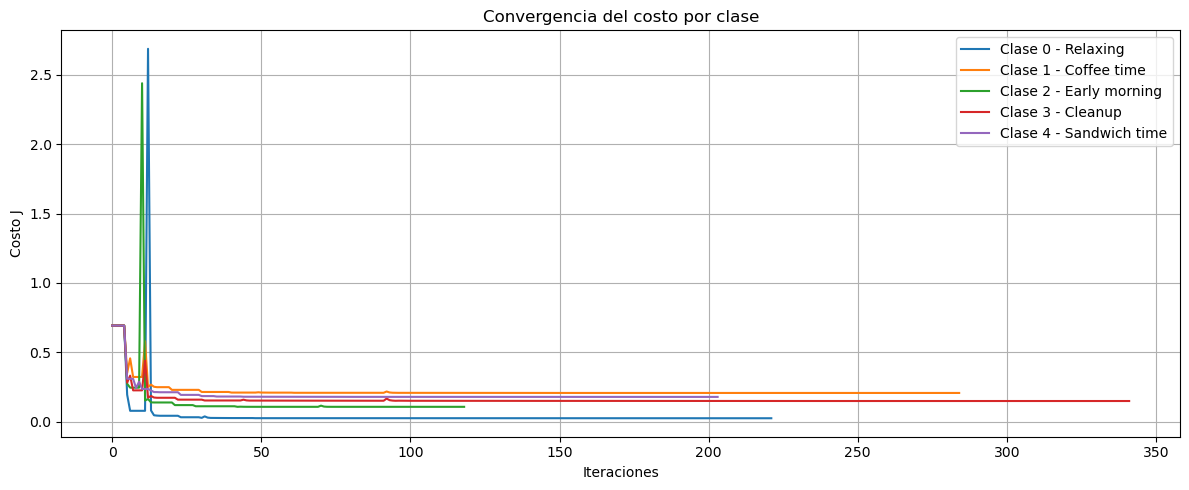

C:\Users\HP\AppData\Local\Temp\ipykernel_19764\701108865.py:6: RuntimeWarning: overflow encountered in exp
  return np.clip(1.0 / (1.0 + np.exp(-z)), 1e-10, 1 - 1e-10)


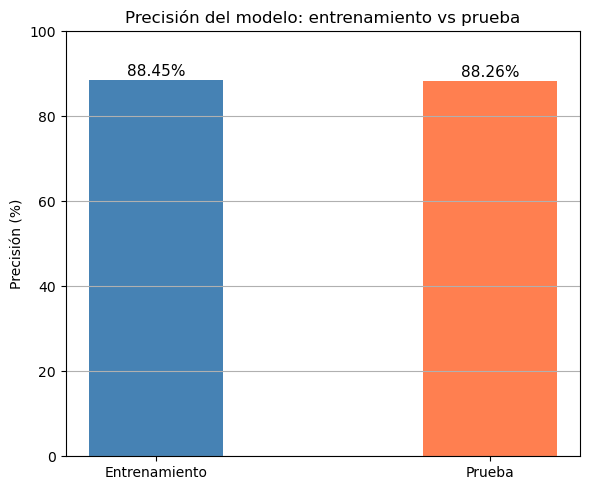

Precisión en entrenamiento: 88.45%


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [19]:
# Nombres de las clases para las gráficas
nombres_clases = {
    0: 'Relaxing',
    1: 'Coffee time',
    2: 'Early morning',
    3: 'Cleanup',
    4: 'Sandwich time'
}

# ── Gráfica 1: Costo por clase ──
pyplot.figure(figsize=(12, 5))

for c in range(num_labels):
    pyplot.plot(historial_costos[c], label=f'Clase {c} - {nombres_clases[c]}')

pyplot.xlabel('Iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del costo por clase')
pyplot.legend()
pyplot.grid(True)
pyplot.tight_layout()
pyplot.show()

# ── Gráfica 2: Precisión entrenamiento vs prueba ──
pred_train = predictOneVsAll(all_theta, X_train_norm)
pred_test  = predictOneVsAll(all_theta, X_test_norm)

precision_train = np.mean(pred_train == y_train) * 100
precision_test  = np.mean(pred_test  == y_test)  * 100

pyplot.figure(figsize=(6, 5))
barras = pyplot.bar(
    ['Entrenamiento', 'Prueba'],
    [precision_train, precision_test],
    color=['steelblue', 'coral'],
    width=0.4
)

# Agregar valores encima de las barras
for barra in barras:
    altura = barra.get_height()
    pyplot.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.3,
        f'{altura:.2f}%',
        ha='center', va='bottom', fontsize=11
    )

pyplot.ylabel('Precisión (%)')
pyplot.title('Precisión del modelo: entrenamiento vs prueba')
pyplot.ylim(0, 100)
pyplot.grid(axis='y')
pyplot.tight_layout()
pyplot.show()

print(f"Precisión en entrenamiento: {precision_train:.2f}%")
print

In [17]:
# Predicción One-vs-All
# Para cada ejemplo calcula la probabilidad de pertenecer a cada clase
# y elige la clase con mayor probabilidad

def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    
    # Agregar término de intercepción
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    
    # Calcular probabilidades para cada clase
    probabilidades = sigmoid(X.dot(all_theta.T))
    
    # Elegir la clase con mayor probabilidad
    return np.argmax(probabilidades, axis=1)

# ── Predecir sobre entrenamiento y prueba ──
pred_train = predictOneVsAll(all_theta, X_train_norm)
pred_test  = predictOneVsAll(all_theta, X_test_norm)

# ── Precisión ──
precision_train = np.mean(pred_train == y_train) * 100
precision_test  = np.mean(pred_test  == y_test)  * 100

print(f"Precisión en entrenamiento: {precision_train:.2f}%")
print(f"Precisión en prueba:        {precision_test:.2f}%")

Precisión en entrenamiento: 88.42%
Precisión en prueba:        88.25%
